# CNN + Genetic Algorithm + Fuzzy Inference System Image Classification

This notebook builds a complete binary image classification pipeline using:

- a Convolutional Neural Network (CNN) for feature learning and prediction,
- a Genetic Algorithm (GA) with `pygad` for hyperparameter optimization, and
- a Fuzzy Inference System (FIS) with `scikit-fuzzy` for the final decision layer.

The dataset is expected to live in `../dataset` relative to this notebook and use filenames like `001_neg.jpg` or `002_pos.png`.

Label mapping used throughout the notebook:

- `neg` -> `0` (`Negative`)
- `pos` -> `1` (`Positive`)


## 1. Dependencies and Environment Setup

Install the required libraries with `uv`:

```powershell
uv add tensorflow scikit-learn opencv-python pygad scikit-fuzzy jupyter matplotlib pandas seaborn
```

If you want the notebook kernel to immediately see the new packages, restart the kernel after installation.


In [2]:
from __future__ import annotations

import gc
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygad
import seaborn as sns
import skfuzzy as fuzz
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from skfuzzy import control as ctrl

SEED = 42
IMAGE_SIZE = (256, 256)
CHANNELS = 3
TEST_SIZE = 0.30
FINAL_VAL_SIZE = 0.20
GA_NUM_SPLITS = 2
GA_NUM_REPEATS = 2
GA_EPOCHS = 12
FINAL_EPOCHS = 20
FITNESS_PATIENCE = 2
FINAL_PATIENCE = 4
DATASET_DIR = Path("../dataset")
ARTIFACTS_DIR = Path("../artifacts")
MODEL_SAVE_PATH = ARTIFACTS_DIR / "cnn_fis_classifier.keras"
HYPERPARAMETERS_PATH = ARTIFACTS_DIR / "best_hyperparameters.json"
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")
print(f"TensorFlow version: {tf.__version__}")
print(f"Dataset directory: {DATASET_DIR.resolve()}")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("TensorFlow can use GPU")
else:
    print("TensorFlow cannot detect GPU")

I0000 00:00:1779374375.447448  257144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779374381.217175  257144 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779374395.929452  257144 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
Dataset directory: /mnt/c/College_Computer_Science/Semester 6/Soft Comp/soft-computing-final/dataset
TensorFlow can use GPU


## 2. Data Loading and Preprocessing

The helper functions below:

- scan the `dataset` folder for image files,
- extract labels from filenames using the `<number>_<label>` convention,
- resize every image to `256 x 256`,
- normalize pixel values to `[0, 1]`, and
- return both a metadata table and NumPy arrays ready for CNN training.


In [3]:
LABEL_MAP = {"neg": 0, "pos": 1}
LABEL_NAMES = {0: "Negative", 1: "Positive"}


def list_image_files(dataset_dir: Path) -> List[Path]:
    return sorted(
        path
        for path in dataset_dir.glob("**/*")
        if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
    )


def parse_label_from_filename(path: Path) -> int:
    """Extract the trailing filename token and map it into a numeric class."""
    stem_parts = path.stem.lower().split("_")
    if len(stem_parts) < 2:
        raise ValueError(
            f"Filename '{path.name}' does not follow the '<number>_<label>' format."
        )

    raw_label = stem_parts[-1]
    if raw_label not in LABEL_MAP:
        raise ValueError(
            f"Filename '{path.name}' contains label '{raw_label}', expected one of {list(LABEL_MAP)}."
        )
    return LABEL_MAP[raw_label]


def preprocess_image(image_path: Path, image_size: Tuple[int, int] = IMAGE_SIZE) -> np.ndarray:
    """Load an image with OpenCV, convert it to RGB, resize it, and normalize it."""
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, image_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0
    return image


def load_dataset(dataset_dir: Path) -> Tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    records: List[Dict[str, object]] = []
    images: List[np.ndarray] = []
    labels: List[int] = []

    for image_path in list_image_files(dataset_dir):
        label = parse_label_from_filename(image_path)
        image_array = preprocess_image(image_path)

        records.append(
            {
                "path": str(image_path),
                "filename": image_path.name,
                "label": label,
                "label_name": LABEL_NAMES[label],
            }
        )
        images.append(image_array)
        labels.append(label)

    dataframe = pd.DataFrame(records)
    if not images:
        empty_images = np.empty((0, IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS), dtype=np.float32)
        empty_labels = np.empty((0,), dtype=np.int32)
        return dataframe, empty_images, empty_labels

    return dataframe, np.stack(images).astype(np.float32), np.asarray(labels, dtype=np.int32)


def plot_sample_images(images: np.ndarray, labels: np.ndarray, num_samples: int = 8) -> None:
    if len(images) == 0:
        print("No images available to preview.")
        return

    num_samples = min(num_samples, len(images))
    columns = min(4, num_samples)
    rows = int(np.ceil(num_samples / columns))
    figure, axes = plt.subplots(rows, columns, figsize=(4 * columns, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for axis, index in zip(axes, range(num_samples)):
        axis.imshow(images[index])
        axis.set_title(LABEL_NAMES[int(labels[index])])
        axis.axis("off")

    for axis in axes[num_samples:]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


Images found: 100


,path,filename,label,label_name
0,../dataset/001_pos.png,001_pos.png,1,Positive
1,../dataset/002_pos.png,002_pos.png,1,Positive
2,../dataset/003_pos.png,003_pos.png,1,Positive
3,../dataset/004_neg.png,004_neg.png,0,Negative
4,../dataset/005_neg.png,005_neg.png,0,Negative


,class,count
0,Negative,51
1,Positive,49


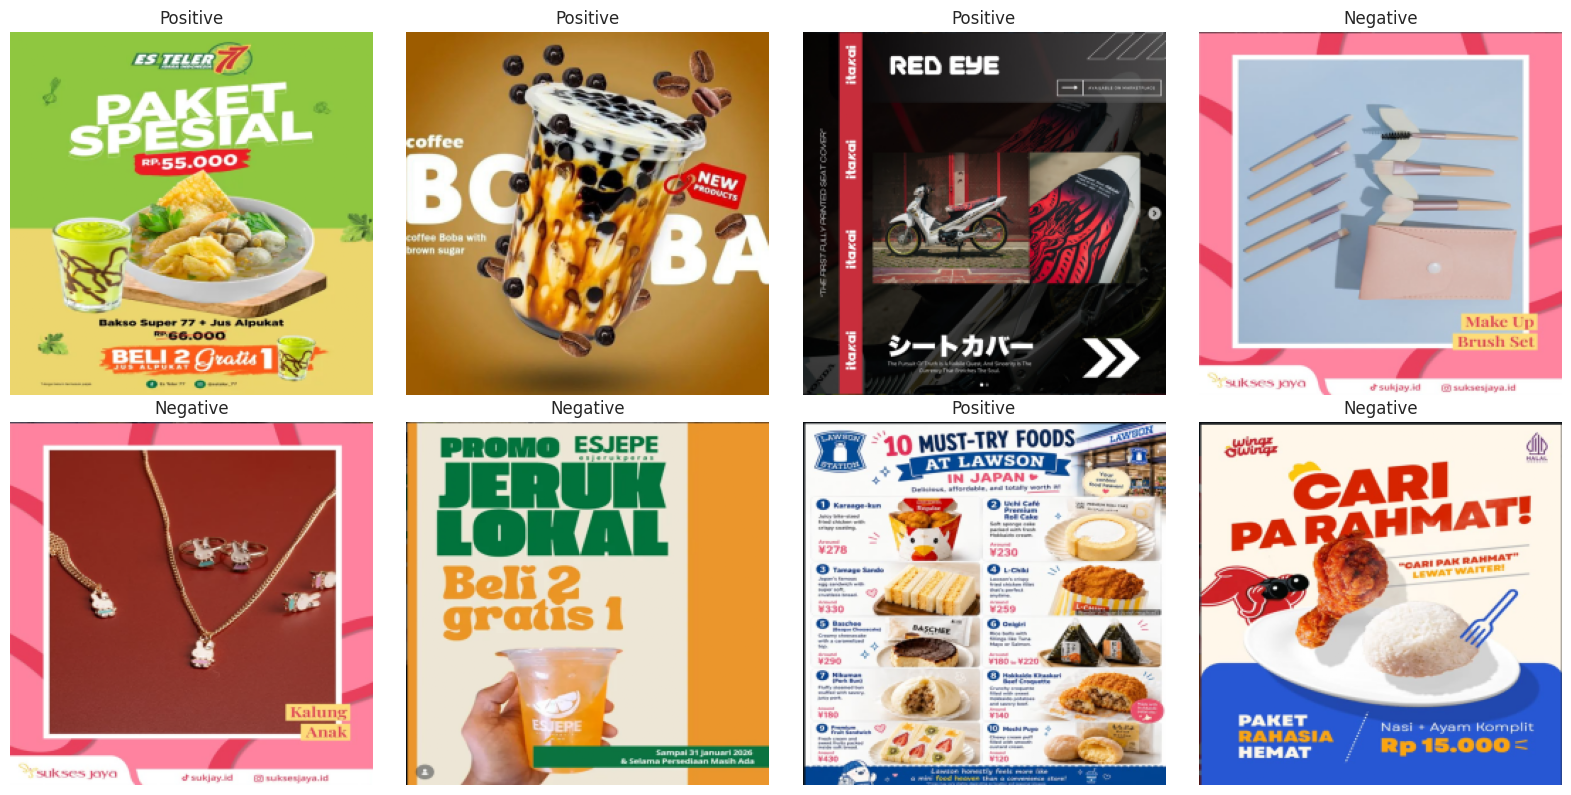

In [4]:
metadata_df, X, y = load_dataset(DATASET_DIR)
DATA_READY = len(metadata_df) > 0

print(f"Images found: {len(metadata_df)}")
if DATA_READY:
    display(metadata_df.head())
    display(metadata_df["label_name"].value_counts().rename_axis("class").reset_index(name="count"))
    plot_sample_images(X, y)
else:
    print(
        "The dataset folder is currently empty. The remaining cells are written and ready, "
        "but training will be skipped until images are added to ../dataset."
    )


## 3. Reliable Evaluation Split and TensorFlow Pipelines

To make the result less sensitive to a tiny validation slice, the notebook now uses:

- one **held-out test set** that is never touched during GA tuning,
- repeated stratified cross-validation on the remaining training pool for the GA fitness score, and
- a small final validation split only for early stopping and training-curve monitoring.

This keeps the final test evaluation cleaner while giving the GA a more stable score than a single 6-image validation set.

In [5]:
def ensure_training_ready(labels: np.ndarray) -> None:
    if len(labels) == 0:
        raise RuntimeError("No images were loaded. Add data to ../dataset and rerun the notebook.")
    if len(np.unique(labels)) < 2:
        raise RuntimeError("At least two classes are required to train the CNN.")

    class_counts = np.bincount(labels)
    if class_counts.min() < 4:
        raise RuntimeError(
            "Each class needs at least 4 images so the held-out split and repeated stratified validation remain valid."
        )

    if len(labels) < 20:
        print(
            "Warning: the dataset is still very small, so results may vary. "
            "The new split strategy is more reliable than before, but more images will still help a lot."
        )


def describe_labels(name: str, labels: np.ndarray) -> None:
    unique, counts = np.unique(labels, return_counts=True)
    distribution = ", ".join(
        f"{LABEL_NAMES[int(label)]}={int(count)}"
        for label, count in zip(unique, counts)
    )
    print(f"{name}: {len(labels)} samples ({distribution})")


def make_splits(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = TEST_SIZE,
    final_val_size: float = FINAL_VAL_SIZE,
    ga_num_splits: int = GA_NUM_SPLITS,
    ga_num_repeats: int = GA_NUM_REPEATS,
    random_state: int = SEED,
) -> Dict[str, np.ndarray]:
    ensure_training_ready(y)

    X_model_train, X_test, y_model_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state,
    )

    X_final_train, X_final_val, y_final_train, y_final_val = train_test_split(
        X_model_train,
        y_model_train,
        test_size=final_val_size,
        stratify=y_model_train,
        random_state=random_state,
    )

    cv = RepeatedStratifiedKFold(
        n_splits=ga_num_splits,
        n_repeats=ga_num_repeats,
        random_state=random_state,
    )
    cv_splits = list(cv.split(X_model_train, y_model_train))

    return {
        "X_model_train": X_model_train,
        "X_final_train": X_final_train,
        "X_final_val": X_final_val,
        "X_test": X_test,
        "y_model_train": y_model_train,
        "y_final_train": y_final_train,
        "y_final_val": y_final_val,
        "y_test": y_test,
        "cv_splits": cv_splits,
    }


def make_tf_dataset(
    features: np.ndarray,
    labels: np.ndarray,
    batch_size: int,
    training: bool = False,
) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((features, labels))
    if training:
        dataset = dataset.shuffle(buffer_size=len(features), seed=SEED, reshuffle_each_iteration=True)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


splits = None
if DATA_READY:
    try:
        splits = make_splits(X, y)
        describe_labels("Full dataset", y)
        describe_labels("GA/final-training pool", splits["y_model_train"])
        describe_labels("Final training split", splits["y_final_train"])
        describe_labels("Final validation split", splits["y_final_val"])
        describe_labels("Held-out test split", splits["y_test"])
        print(
            f"GA cross-validation folds: {len(splits['cv_splits'])} "
            f"({GA_NUM_SPLITS}-fold x {GA_NUM_REPEATS} repeats)"
        )
    except RuntimeError as error:
        print(error)
else:
    print("Skipping split creation until dataset images are added.")

Full dataset: 100 samples (Negative=51, Positive=49)
GA/final-training pool: 70 samples (Negative=36, Positive=34)
Final training split: 56 samples (Negative=29, Positive=27)
Final validation split: 14 samples (Negative=7, Positive=7)
Held-out test split: 30 samples (Negative=15, Positive=15)
GA cross-validation folds: 4 (2-fold x 2 repeats)


## 4. CNN Architecture

This notebook variant uses a CNN trained from scratch, without transfer learning.

- image augmentation is applied only during training,
- the GA tunes the CNN architecture and training hyperparameters directly,
- and the final output remains a single sigmoid probability for the `Positive` class.

In [16]:
@dataclass(frozen=True)
class CNNHyperParameters:
    learning_rate: float
    filters_1: int
    filters_2: int
    dense_units: int
    dropout_rate: float
    batch_size: int


def build_data_augmentation() -> tf.keras.Sequential:
    return tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
            tf.keras.layers.RandomRotation(0.08, fill_mode="reflect", seed=SEED),
            tf.keras.layers.RandomZoom(0.10, seed=SEED),
            tf.keras.layers.RandomTranslation(0.08, 0.08, fill_mode="reflect", seed=SEED),
            tf.keras.layers.RandomContrast(0.10, seed=SEED),
        ],
        name="data_augmentation",
    )


def build_cnn_model(
    input_shape: Tuple[int, int, int],
    hyperparameters: CNNHyperParameters,
    use_augmentation: bool = True,
) -> tf.keras.Model:
    layers: List[tf.keras.layers.Layer] = [tf.keras.layers.Input(shape=input_shape)]

    if use_augmentation:
        layers.append(build_data_augmentation())

    layers.extend(
        [
            tf.keras.layers.Conv2D(hyperparameters.filters_1, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Conv2D(hyperparameters.filters_2, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Conv2D(hyperparameters.filters_2, (3, 3), activation="relu", padding="same"),
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.Dense(hyperparameters.dense_units, activation="relu"),
            tf.keras.layers.Dropout(hyperparameters.dropout_rate),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ]
    )

    model = tf.keras.Sequential(layers)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hyperparameters.learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


example_hparams = CNNHyperParameters(
    learning_rate=1e-3,
    filters_1=64,
    filters_2=96,
    dense_units=128,
    dropout_rate=0.3,
    batch_size=8,
)

build_cnn_model((IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS), example_hparams).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 96)   │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 96)     │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,769 (596.75 KB)

 Trainable params: 152,769 (596.75 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Hyperparameter Optimization with a Genetic Algorithm

The GA in this notebook variant tunes a CNN trained from scratch.

Each chromosome controls:

- learning rate,
- convolution filters in the first block,
- convolution filters in the deeper blocks,
- dense classification-head width,
- dropout rate, and
- batch size.

Each candidate is evaluated with repeated stratified cross-validation, and the GA fitness is the mean best validation accuracy across folds.

In [ ]:
GENE_SPACE = [
    [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3],  # learning_rate
    [16, 32, 48, 64, 96],                      # filters_1
    [96, 128, 192, 224, 256],                   # filters_2
    list(range(32, 257, 32)),              # dense_units
    [0.1, 0.2, 0.3, 0.4, 0.5],        # dropout_rate
    [4, 8, 12, 16],                        # batch_size
]

GENE_NAMES = [
    "learning_rate",
    "filters_1",
    "filters_2",
    "dense_units",
    "dropout_rate",
    "batch_size",
]


def decode_solution(solution: np.ndarray) -> CNNHyperParameters:
    values = {name: val for name, val in zip(GENE_NAMES, solution)}
    filters_1 = int(values["filters_1"])
    filters_2 = int(values["filters_2"])

    return CNNHyperParameters(
        learning_rate=float(values["learning_rate"]),
        filters_1=filters_1,
        filters_2=filters_2,
        dense_units=int(values["dense_units"]),
        dropout_rate=float(values["dropout_rate"]),
        batch_size=int(values["batch_size"]),
    )


def make_fitness_function(splits: Dict[str, np.ndarray]):
    X_model_train = splits["X_model_train"]
    y_model_train = splits["y_model_train"]
    cv_splits = splits["cv_splits"]

    def fitness_func(ga_instance: pygad.GA, solution: np.ndarray, solution_idx: int) -> float:
        hyperparameters = decode_solution(solution)
        fold_scores: List[float] = []

        try:
            for train_indices, val_indices in cv_splits:
                tf.keras.backend.clear_session()
                gc.collect()

                model = build_cnn_model(
                    (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS),
                    hyperparameters,
                )

                train_dataset = make_tf_dataset(
                    X_model_train[train_indices],
                    y_model_train[train_indices],
                    batch_size=hyperparameters.batch_size,
                    training=True,
                )
                val_dataset = make_tf_dataset(
                    X_model_train[val_indices],
                    y_model_train[val_indices],
                    batch_size=hyperparameters.batch_size,
                    training=False,
                )

                callbacks = [
                    tf.keras.callbacks.EarlyStopping(
                        monitor="val_accuracy",
                        mode="max",
                        patience=FITNESS_PATIENCE,
                        restore_best_weights=True,
                    ),
                ]

                history = model.fit(
                    train_dataset,
                    validation_data=val_dataset,
                    epochs=GA_EPOCHS,
                    verbose=0,
                    callbacks=callbacks,
                )
                fold_scores.append(float(max(history.history["val_accuracy"])))

            return float(np.mean(fold_scores))
        except tf.errors.ResourceExhaustedError:
            return 0.0
        finally:
            tf.keras.backend.clear_session()
            gc.collect()

    return fitness_func


def run_ga_search(splits: Dict[str, np.ndarray]) -> Tuple[pygad.GA, CNNHyperParameters]:
    ga_instance = pygad.GA(
        num_generations=6,
        num_parents_mating=3,
        sol_per_pop=3,
        num_genes=len(GENE_SPACE),
        gene_space=GENE_SPACE,
        fitness_func=make_fitness_function(splits),
        parent_selection_type="tournament",
        keep_elitism=1,
        crossover_type="single_point",
        mutation_type="random",
        mutation_percent_genes=25,
        random_seed=SEED,
        save_solutions=True,
        suppress_warnings=True,
    )
    ga_instance.run()
    best_solution, best_solution_fitness, _ = ga_instance.best_solution()
    best_hyperparameters = decode_solution(best_solution)
    print(
        f"Best mean validation accuracy from GA: {best_solution_fitness:.4f} "
        f"across {len(splits['cv_splits'])} validation folds"
    )
    print(best_hyperparameters)
    return ga_instance, best_hyperparameters

In [8]:
ga_instance = None
best_hyperparameters = None

if splits is not None:
    ga_instance, best_hyperparameters = run_ga_search(splits)
else:
    print("Skipping GA because the dataset is not ready for training yet.")


I0000 00:00:1779374425.890423  257452 cuda_dnn.cc:461] Loaded cuDNN version 92200
W0000 00:00:1779374503.734617  257456 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 6.11GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1779374649.060340  257453 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.30GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1779374649.836657  257449 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.09GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Best mean validation accuracy from GA: 0.5286 across 4 validation folds
CNNHyperParameters(learning_rate=0.003, filters_1=96, filters_2=256, dense_units=64, dropout_rate=0.5, batch_size=16)


## 6. Final CNN Training with the Best Hyperparameters

After the GA selects the best pure-CNN configuration, the notebook rebuilds the model and trains it once more:

- the model trains on the dedicated final training split,
- a separate validation split is used for early stopping and learning-rate reduction,
- and the untouched held-out test set is evaluated only after training finishes.

In [18]:
final_model = None
final_history = None
test_dataset = None

if splits is not None:
    if best_hyperparameters is None:
        best_hyperparameters = example_hparams
        print("GA was skipped, so the example hyperparameters will be used for final training.")

    tf.keras.backend.clear_session()
    final_model = build_cnn_model(
        (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS),
        best_hyperparameters,
    )

    train_dataset = make_tf_dataset(
        splits["X_final_train"],
        splits["y_final_train"],
        batch_size=best_hyperparameters.batch_size,
        training=True,
    )
    val_dataset = make_tf_dataset(
        splits["X_final_val"],
        splits["y_final_val"],
        batch_size=best_hyperparameters.batch_size,
        training=False,
    )
    test_dataset = make_tf_dataset(
        splits["X_test"],
        splits["y_test"],
        batch_size=best_hyperparameters.batch_size,
        training=False,
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            mode="max",
            patience=FINAL_PATIENCE,
            restore_best_weights=True,
        ),
    ]

    final_history = final_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=FINAL_EPOCHS,
        verbose=1,
        callbacks=callbacks,
    )

    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    final_model.save(MODEL_SAVE_PATH)
    with HYPERPARAMETERS_PATH.open("w", encoding="utf-8") as file:
        json.dump(best_hyperparameters.__dict__, file, indent=2)
    print(f"Saved trained model to: {MODEL_SAVE_PATH.resolve()}")
    print(f"Saved best hyperparameters to: {HYPERPARAMETERS_PATH.resolve()}")

    final_val_loss, final_val_accuracy = final_model.evaluate(val_dataset, verbose=0)
    test_loss, test_accuracy = final_model.evaluate(test_dataset, verbose=0)
    print(f"Final validation loss: {final_val_loss:.4f}")
    print(f"Final validation accuracy: {final_val_accuracy:.4f}")
    print(f"Held-out test loss: {test_loss:.4f}")
    print(f"Held-out test accuracy: {test_accuracy:.4f}")
else:
    print("Skipping final training because the dataset is not ready.")

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 190ms/step - accuracy: 0.5714 - loss: 0.8240 - val_accuracy: 0.5714 - val_loss: 0.6930
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.4464 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.4107 - loss: 0.6975 - val_accuracy: 0.5714 - val_loss: 0.6934
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.5179 - loss: 0.6928 - val_accuracy: 0.5714 - val_loss: 0.6931
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.5357 - loss: 0.6941 - val_accuracy: 0.5000 - val_loss: 0.6932
Saved trained model to: /mnt/c/College_Computer_Science/Semester 6/Soft Comp/soft-computing-final/artifacts/cnn_fis_classifier.keras
Saved best hyperparameters to: /mnt/c/College_Computer_Science/Semester 6/Soft Comp/soft-computing-final/artifacts/best_hyperparameters.json
Final validation loss: 0.6930
Final validation accuracy: 0.5714
Held-out test loss: 0.6928
Held-out

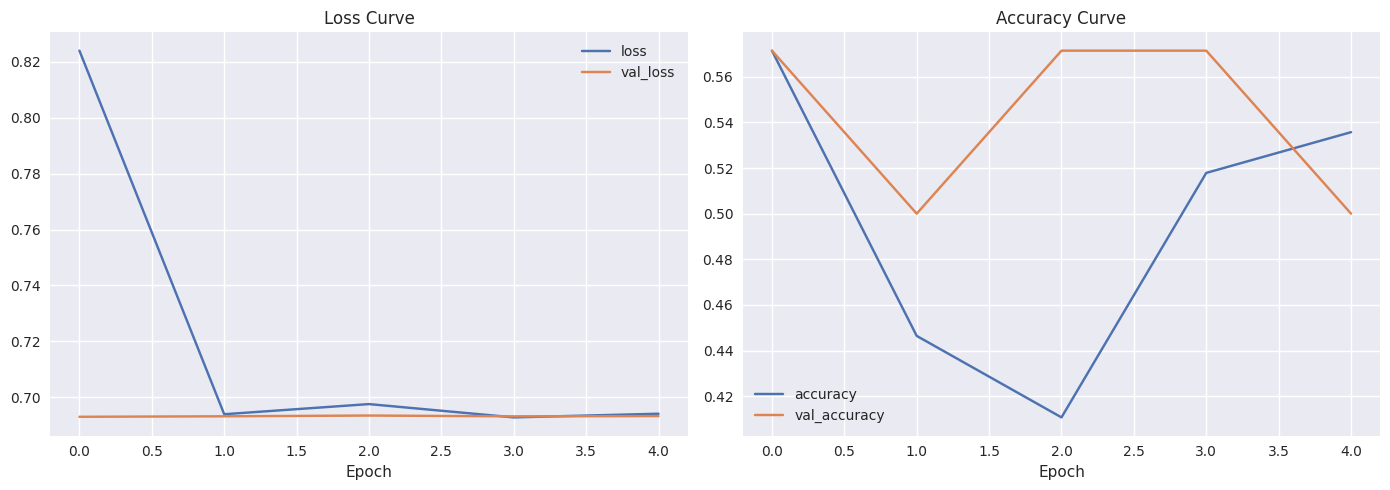

In [19]:
if final_history is not None:
    history_df = pd.DataFrame(final_history.history)
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))

    history_df[["loss", "val_loss"]].plot(ax=axes[0], title="Loss Curve")
    history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy Curve")

    axes[0].set_xlabel("Epoch")
    axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()
else:
    print("No final training history to visualize yet.")


## 7. Fuzzy Inference System (FIS) for the Final Decision

The CNN outputs a probability for the positive class. We convert that into two confidence inputs:

- `positive_confidence = P(Positive)`
- `negative_confidence = 1 - P(Positive)`

A fuzzy system then maps those confidence values into one of three decision categories:

- `Negative`
- `Other/Uncertain`
- `Positive`

This is useful when probabilities are ambiguous, because the FIS can explicitly represent uncertainty instead of forcing every sample into a hard binary class.


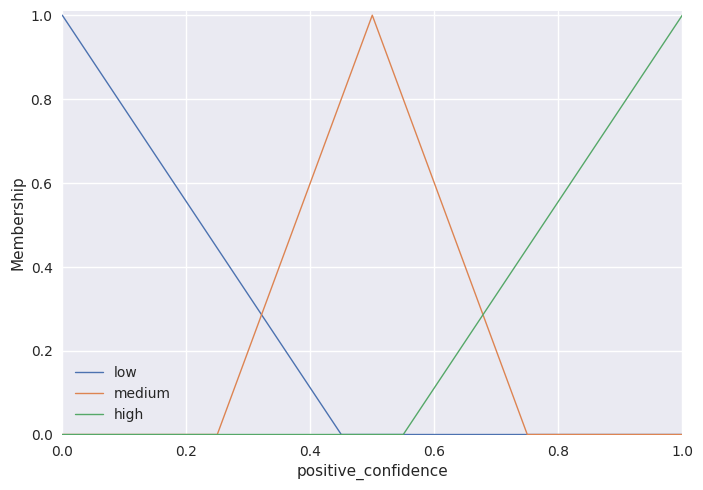

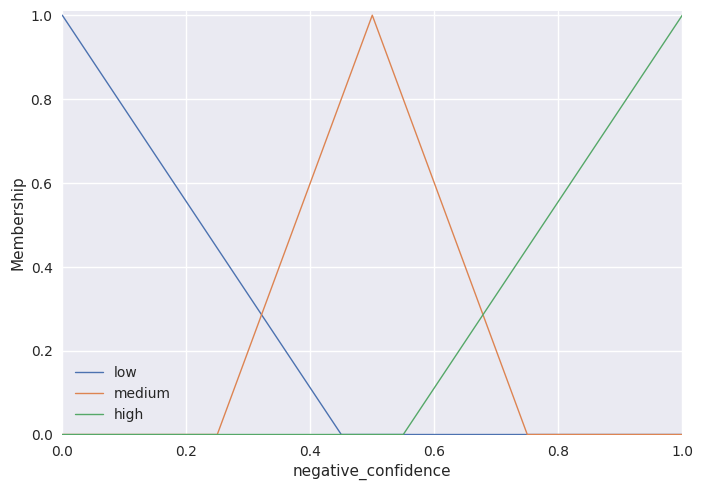

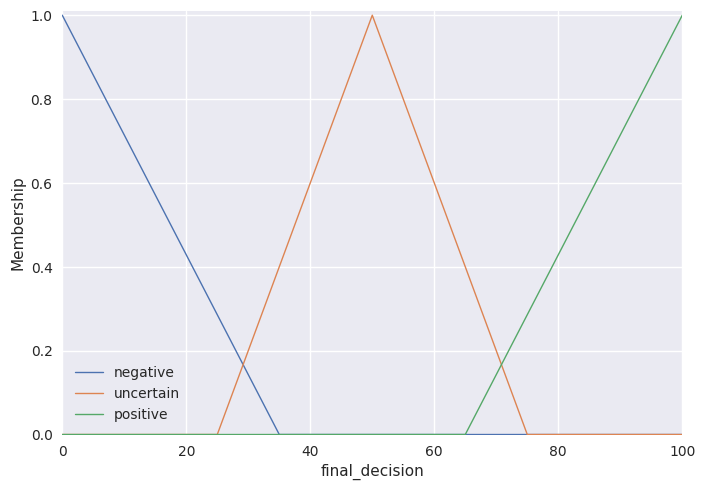

In [26]:
def build_fuzzy_system() -> ctrl.ControlSystemSimulation:
    positive_confidence = ctrl.Antecedent(np.linspace(0, 1, 101), "positive_confidence")
    negative_confidence = ctrl.Antecedent(np.linspace(0, 1, 101), "negative_confidence")
    final_decision = ctrl.Consequent(np.linspace(0, 100, 101), "final_decision")

    for variable in (positive_confidence, negative_confidence):
        variable["low"] = fuzz.trimf(variable.universe, [0.0, 0.0, 0.45])
        variable["medium"] = fuzz.trimf(variable.universe, [0.25, 0.5, 0.75])
        variable["high"] = fuzz.trimf(variable.universe, [0.55, 1.0, 1.0])

    final_decision["negative"] = fuzz.trimf(final_decision.universe, [0, 0, 35])
    final_decision["uncertain"] = fuzz.trimf(final_decision.universe, [25, 50, 75])
    final_decision["positive"] = fuzz.trimf(final_decision.universe, [65, 100, 100])

    rules = [
        ctrl.Rule(positive_confidence["high"] & negative_confidence["low"], final_decision["positive"]),
        ctrl.Rule(positive_confidence["medium"] & negative_confidence["low"], final_decision["positive"]),
        ctrl.Rule(negative_confidence["high"] & positive_confidence["low"], final_decision["negative"]),
        ctrl.Rule(negative_confidence["medium"] & positive_confidence["low"], final_decision["negative"]),
        ctrl.Rule(positive_confidence["medium"] & negative_confidence["medium"], final_decision["uncertain"]),
        ctrl.Rule(positive_confidence["high"] & negative_confidence["high"], final_decision["uncertain"]),
        ctrl.Rule(positive_confidence["low"] & negative_confidence["low"], final_decision["uncertain"]),
    ]

    control_system = ctrl.ControlSystem(rules)
    return ctrl.ControlSystemSimulation(control_system)


def fuzzy_label_from_probabilities(
    positive_probability: float,
    negative_probability: float | None = None,
) -> Tuple[str, float]:
    if negative_probability is None:
        negative_probability = 1.0 - positive_probability

    fuzzy_system = build_fuzzy_system()
    fuzzy_system.input["positive_confidence"] = float(positive_probability)
    fuzzy_system.input["negative_confidence"] = float(negative_probability)
    fuzzy_system.compute()

    decision_score = float(fuzzy_system.output["final_decision"])
    if decision_score >= 65:
        label = "Positive"
    elif decision_score <= 35:
        label = "Negative"
    else:
        label = "Other/Uncertain"

    return label, decision_score


fis_sim = build_fuzzy_system()
control_system = fis_sim.ctrl

# 2. Show membership function plots
for antecedent in list(control_system.antecedents):
    antecedent.view()
    plt.show()

for consequent in list(control_system.consequents):
    consequent.view()
    plt.show()

,true_label,true_label_name,positive_probability,negative_probability,cnn_prediction,cnn_prediction_name,fis_label,fis_score
0,0,Negative,0.500071,0.499929,1,Positive,Other/Uncertain,50.0
1,0,Negative,0.499762,0.500238,0,Negative,Other/Uncertain,50.0
2,1,Positive,0.499647,0.500353,0,Negative,Other/Uncertain,50.0
3,0,Negative,0.499208,0.500792,0,Negative,Other/Uncertain,50.0
4,0,Negative,0.500099,0.499901,1,Positive,Other/Uncertain,50.0
5,1,Positive,0.500657,0.499343,1,Positive,Other/Uncertain,50.0
6,1,Positive,0.499899,0.500101,0,Negative,Other/Uncertain,50.0
7,1,Positive,0.500226,0.499774,1,Positive,Other/Uncertain,50.0
8,1,Positive,0.500140,0.499860,1,Positive,Other/Uncertain,50.0
9,0,Negative,0.499329,0.500671,0,Negative,Other/Uncertain,50.0


Held-out CNN classification report:
              precision    recall  f1-score   support

    Negative       0.61      0.73      0.67        15
    Positive       0.67      0.53      0.59        15

    accuracy                           0.63        30
   macro avg       0.64      0.63      0.63        30
weighted avg       0.64      0.63      0.63        30



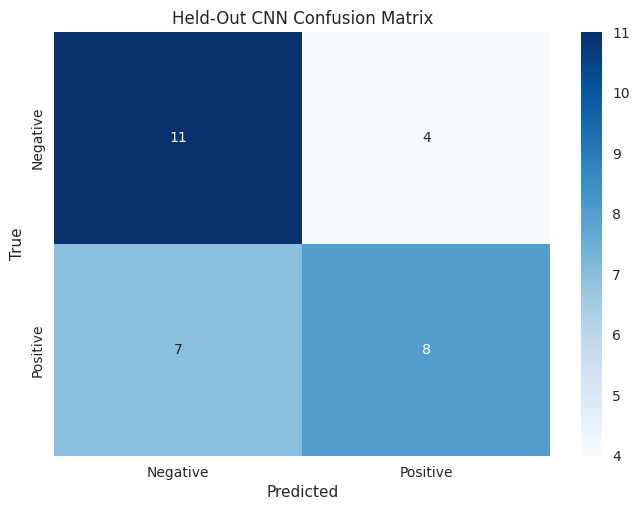

FIS decision counts:


,fis_label,count
0,Other/Uncertain,30


In [29]:
results_df = None

if final_model is not None and test_dataset is not None and splits is not None:
    positive_probabilities = final_model.predict(test_dataset, verbose=0).reshape(-1)
    negative_probabilities = 1.0 - positive_probabilities
    cnn_predictions = (positive_probabilities >= 0.5).astype(int)

    fuzzy_outputs = [
        fuzzy_label_from_probabilities(pos_prob, neg_prob)
        for pos_prob, neg_prob in zip(positive_probabilities, negative_probabilities)
    ]

    results_df = pd.DataFrame(
        {
            "true_label": splits["y_test"],
            "true_label_name": [LABEL_NAMES[int(label)] for label in splits["y_test"]],
            "positive_probability": positive_probabilities,
            "negative_probability": negative_probabilities,
            "cnn_prediction": cnn_predictions,
            "cnn_prediction_name": [LABEL_NAMES[int(label)] for label in cnn_predictions],
            "fis_label": [label for label, _ in fuzzy_outputs],
            "fis_score": [score for _, score in fuzzy_outputs],
        }
    )

    display(results_df.head(50))

    print("Held-out CNN classification report:")
    print(
        classification_report(
            splits["y_test"],
            cnn_predictions,
            target_names=["Negative", "Positive"],
            zero_division=0,
        )
    )

    confusion = confusion_matrix(splits["y_test"], cnn_predictions)
    sns.heatmap(
        confusion,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
    )
    plt.title("Held-Out CNN Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("FIS decision counts:")
    display(results_df["fis_label"].value_counts().rename_axis("fis_label").reset_index(name="count"))
else:
    print("Skipping FIS evaluation because the final CNN model is not available yet.")

## 8. Inference Helper for New Images

Use the helper below to score any folder of images after the final CNN has been trained. The fuzzy layer will return `Positive`, `Negative`, or `Other/Uncertain` for each image.


In [30]:
def predict_folder_with_fis(folder_path: str | Path, model: tf.keras.Model) -> pd.DataFrame:
    folder = Path(folder_path)
    image_paths = [path for path in list_image_files(folder)]
    if not image_paths:
        raise ValueError(f"No supported image files found in: {folder.resolve()}")

    image_arrays = np.stack([preprocess_image(path) for path in image_paths]).astype(np.float32)
    positive_probabilities = model.predict(image_arrays, verbose=0).reshape(-1)
    negative_probabilities = 1.0 - positive_probabilities

    predictions = []
    for image_path, pos_prob, neg_prob in zip(image_paths, positive_probabilities, negative_probabilities):
        fuzzy_label, fuzzy_score = fuzzy_label_from_probabilities(pos_prob, neg_prob)
        predictions.append(
            {
                "filename": image_path.name,
                "positive_probability": float(pos_prob),
                "negative_probability": float(neg_prob),
                "fis_label": fuzzy_label,
                "fis_score": fuzzy_score,
            }
        )

    return pd.DataFrame(predictions)


# Example usage after training:
# reloaded_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
# predict_folder_with_fis(DATASET_DIR, reloaded_model).head()
